**Predicting Popularity in Online Dating Apps**

**Authors:**  
- Arkadii Shekhovtsov - Linear Regression 
- Egor Novikov - Decision Tree
- Rumeysa Mercimek - Random Forest
- Evgenii Strizhak - Neural Network

Data analysis + feature engineering - together

**Course:** Data Science Project  
**Date:** June 2025

---

**Problem Statement**

The goal of this project is to predict the popularity of online dating app users (i.e., the number of matches or popularity class), based on their profile features and activity. We aim to determine which factors most influence a user's popularity and to build machine learning models that can accurately classify or predict this metric.

---

**Data Set**

- **Source:** [Kaggle: Predict Online Dating Matches Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predict-online-dating-matches-dataset)
- **Description:**  
  The dataset contains user information such as gender, age, attractiveness, VIP status, income, children, and the number of matches.  
  - 1000 users, 7 features + target variable.
  - No missing values.

---

**Selected Models**

- **Linear Regression**
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **Neural Network (Keras/Tensorflow)**

---

**Model Selection Rationale and Parameters** 

**Linear Regression:**  
We started with linear regression as a simple baseline for predicting the number of matches as a continuous variable. This model provides interpretability and a straightforward analysis of feature importance.  

**Decision Tree Classifier:**  
Chosen for its ability to capture non-linear relationships and provide visualizable decision rules. Decision trees are easy to interpret and work well with categorical and numerical features.  

**Random Forest Classifier:**  
Selected for its robustness and improved accuracy over single trees, by combining the predictions of multiple decision trees and reducing overfitting. Suitable for both classification and regression tasks.  

**Neural Network (Keras/TensorFlow):**  
Used to test the performance of a more complex, non-linear model. Neural networks can model interactions between features that simpler models might miss.   

Each model was evaluated using appropriate metrics to compare their effectiveness in predicting user popularity.

---

**Evaluation Criterion**

- **Regression tasks:** Mean Absolute Error (MAE), Mean Squared Error (MSE), R² Score
- **Classification tasks:** Accuracy, Classification Report, Confusion Matrix, Cross-Validation

---

**Results**

- **Linear Regression:** MAE ≈ 18; low accuracy in predicting exact match counts.
- **Decision Tree Classifier:** Good classification performance; key features: Attractiveness, PurchasedVIP, Gender.
- **Random Forest:** Cross-validated accuracy ≈ 0.91 (91%).
- **Neural Network:** No significant improvement over simpler models due to dataset simplicity and clear feature importance.

---

# Imports and loads

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [87]:
df = pd.read_csv("/kaggle/input/predict-online-dating-matches-dataset/Online_Dating_Behavior_Dataset.csv")

In [88]:
df.info()
display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Gender          1000 non-null   int64
 1   PurchasedVIP    1000 non-null   int64
 2   Income          1000 non-null   int64
 3   Children        1000 non-null   int64
 4   Age             1000 non-null   int64
 5   Attractiveness  1000 non-null   int64
 6   Matches         1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


,Gender,PurchasedVIP,Income,Children,Age,Attractiveness,Matches
0,0,1,51777,3,47,5,70
1,1,0,36646,0,42,7,130
2,0,0,53801,1,25,5,0
3,0,0,56105,0,35,8,0
4,0,0,55597,1,36,6,0


,Gender,PurchasedVIP,Income,Children,Age,Attractiveness,Matches
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.51000,0.474000,50988.447000,0.978000,34.616000,5.624000,76.05000
std,0.50015,0.499573,9889.336141,0.997251,9.147799,2.824288,52.71315
min,0.00000,0.000000,20786.000000,0.000000,18.000000,1.000000,0.00000
25%,0.00000,0.000000,44358.500000,0.000000,27.000000,3.000000,0.00000
50%,1.00000,0.000000,50841.500000,1.000000,35.000000,6.000000,70.00000
75%,1.00000,1.000000,57396.000000,2.000000,43.000000,8.000000,120.00000
max,1.00000,1.000000,81931.000000,3.000000,49.000000,10.000000,160.00000


The dataset contains of 7 raws and 1000 columns. There is no skipped data. We can continue with the exploritary data analysis.

# EDA

## Matches (Target feature)

In [89]:
display(df['Matches'].value_counts())

Matches
70     267
0      259
130     64
150     61
100     61
120     58
160     53
80      48
90      47
140     42
110     40
Name: count, dtype: int64

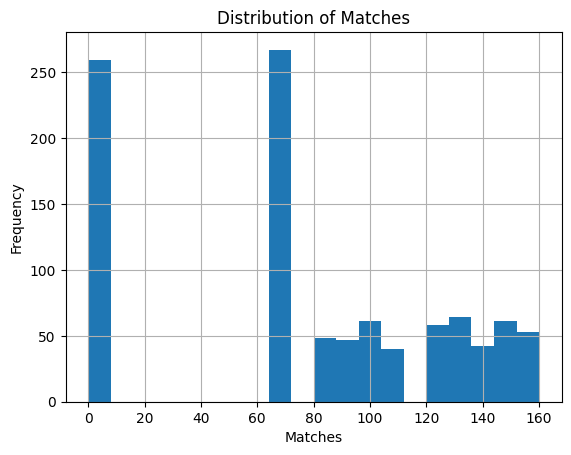

In [90]:
df['Matches'].hist(bins=20)
plt.title('Distribution of Matches')
plt.xlabel('Matches')
plt.ylabel('Frequency')
plt.show()

Very strange numbers, all can be divided by 10. Еhis is uncommon in real-world data, where match counts would typically vary more continuously.
We can  suggest that the data might have been aggregated, anonymized due to policy of the platform.
I think it will be more rellevant to change target feature to "popularity groups"

- Not popular: 0 matches
- Medium poopularity: 1 - 70
- Very popular: 71 - 160

## Gender, VIP, Childrens, Attractiveness

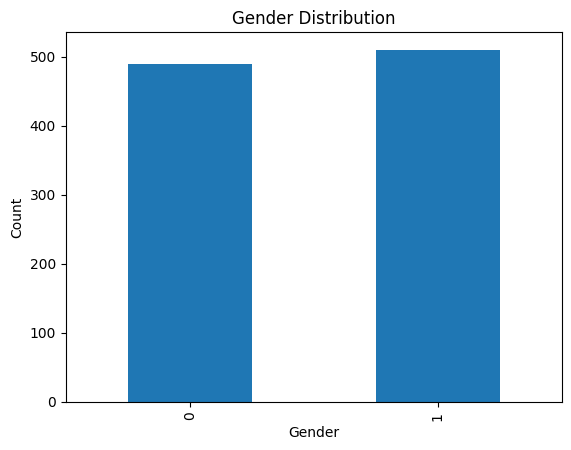

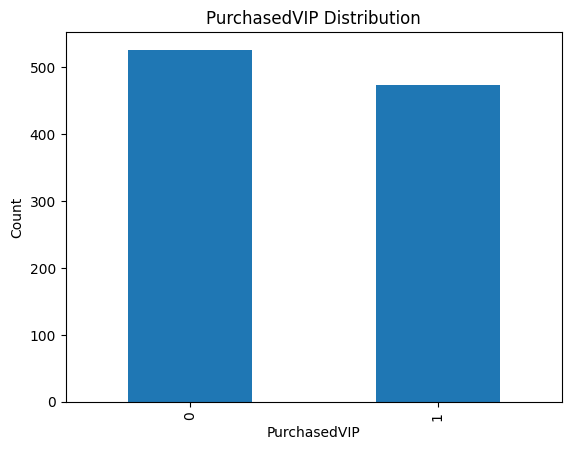

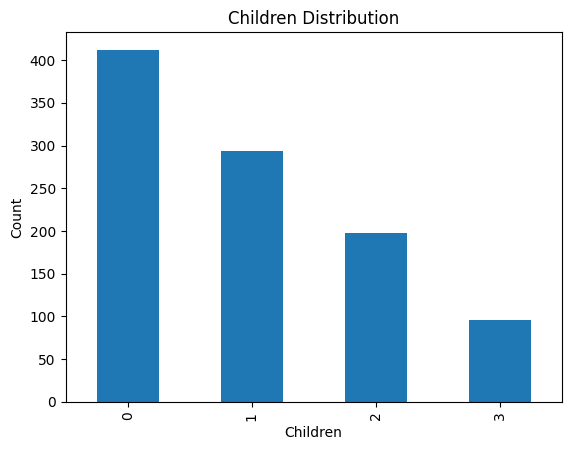

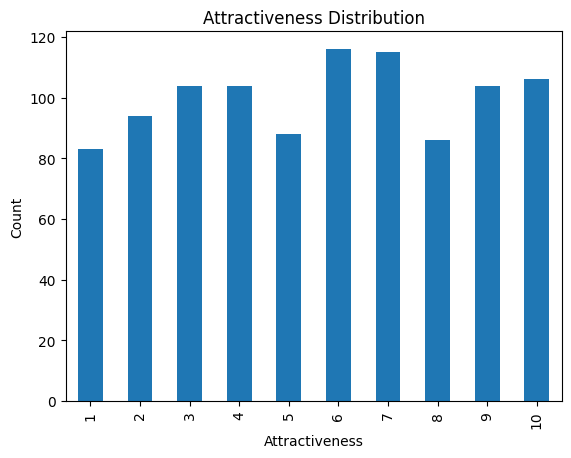

In [91]:
# Plot distributions for categorical features
categorical_features = ['Gender', 'PurchasedVIP', 'Children', 'Attractiveness']
for col in categorical_features:
    if col in df.columns:
        df[col].value_counts().sort_index().plot(kind='bar')
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

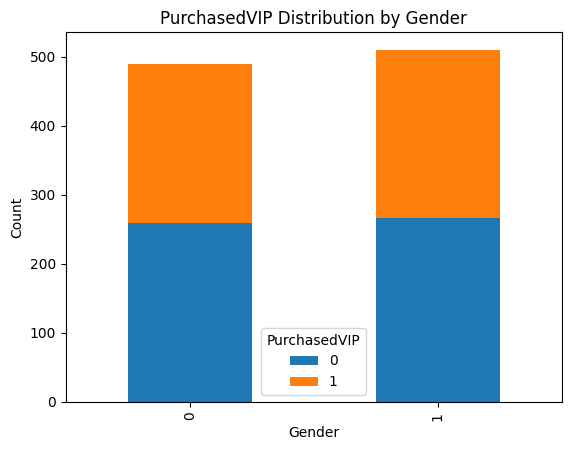

In [92]:
vip_gender = df.groupby(['Gender', 'PurchasedVIP']).size().unstack(fill_value=0)
vip_gender.plot(kind='bar', stacked=True)
plt.title('PurchasedVIP Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Looks like the dataset was collected in such a way that there is no imbalance in data such as attractiveness, gender or purchased wip.

## Income, Age

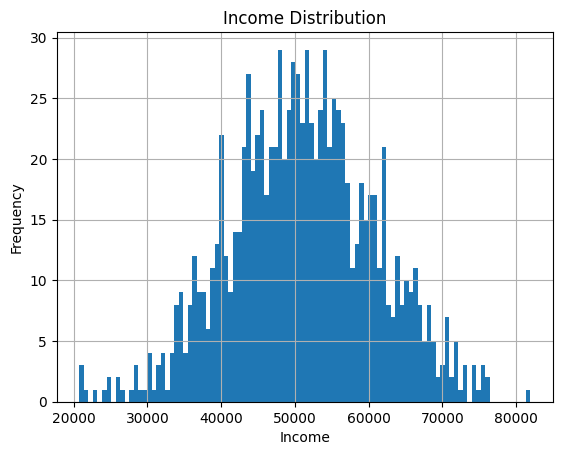

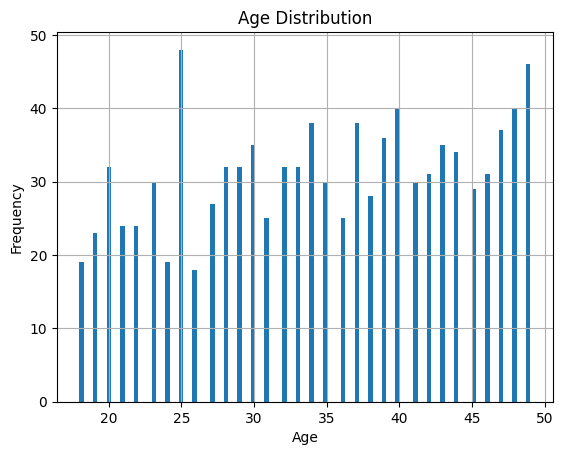

In [93]:
numeric_features = ['Income', 'Age']
for col in numeric_features:
    if col in df.columns:
        df[col].hist(bins=100)
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

The income and age distribution also don't have outliers.

## Correlation Matrics

,Gender,PurchasedVIP,Income,Children,Age,Attractiveness,Matches
Gender,1.000000,0.005048,0.035241,0.012483,-0.007911,0.042348,0.800911
PurchasedVIP,0.005048,1.000000,-0.019903,-0.011195,-0.011167,0.036341,0.338011
Income,0.035241,-0.019903,1.000000,0.030169,0.025023,0.005526,0.007140
Children,0.012483,-0.011195,0.030169,1.000000,-0.022982,0.035444,0.016435
Age,-0.007911,-0.011167,0.025023,-0.022982,1.000000,-0.050848,-0.043462
Attractiveness,0.042348,0.036341,0.005526,0.035444,-0.050848,1.000000,0.313557
Matches,0.800911,0.338011,0.007140,0.016435,-0.043462,0.313557,1.000000


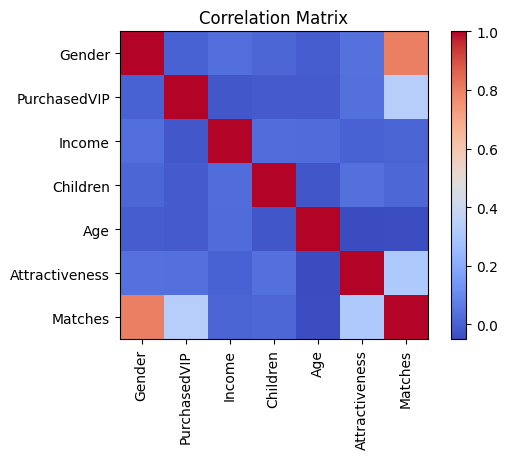

In [94]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
display(corr)

plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Matrix')
plt.show()

The most important feature for successful matching is "Gender". "Atrractiveness" and "PurchasedVIP" can also influence your popularity.

# Feature Engineering

## TargetFeatures

In [95]:
df['MatchesGroup'] = df['Matches']

df['PopularityClass'] = pd.cut(
    df['Matches'],
    bins=[-1, 0, 71, 130, df['Matches'].max()],
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

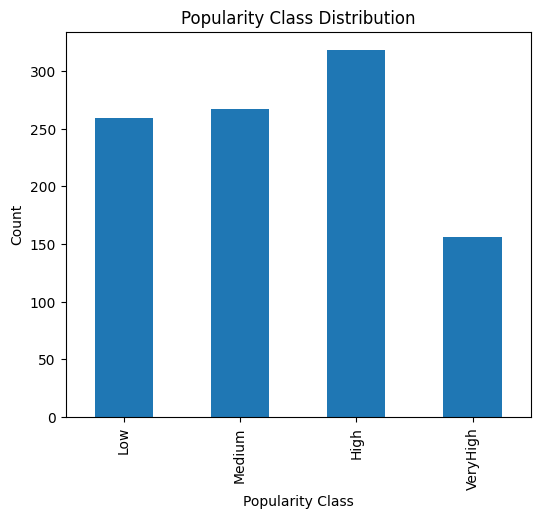

In [96]:
plt.figure(figsize=(6, 5))
df['PopularityClass'].value_counts().sort_index().plot(kind='bar')
plt.title('Popularity Class Distribution')
plt.xlabel('Popularity Class')
plt.ylabel('Count')
plt.show()

## Income and age groups

In [97]:
df['IncomeGroup'] = pd.cut(
    df['Income'],
    bins=[-1, df['Income'].quantile(0.33), df['Income'].quantile(0.66), df['Income'].max()],
    labels=['LowIncome', 'MidIncome', 'HighIncome']
)

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[-1, df['Age'].quantile(0.33), df['Age'].quantile(0.66), df['Age'].max()],
    labels=['Young', 'MidAge', 'Old']
)

## Encoding

In [98]:
df['GenderEncoded'] = LabelEncoder().fit_transform(df['Gender'])
df['IncomeGroupEncoded'] = LabelEncoder().fit_transform(df['IncomeGroup'])
df['AgeGroupEncoded'] = LabelEncoder().fit_transform(df['AgeGroup'])

# Baseline model

## Model train

In [99]:
X = df[['PurchasedVIP', 'Income', 'Children', 'Age', 'AgeGroupEncoded', 'IncomeGroupEncoded', 'Attractiveness', 'GenderEncoded']]
y = df['MatchesGroup']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

## Prediction

MAE: 18.937385469958127
MSE: 522.263462718869
R^2: 0.8083148427033539


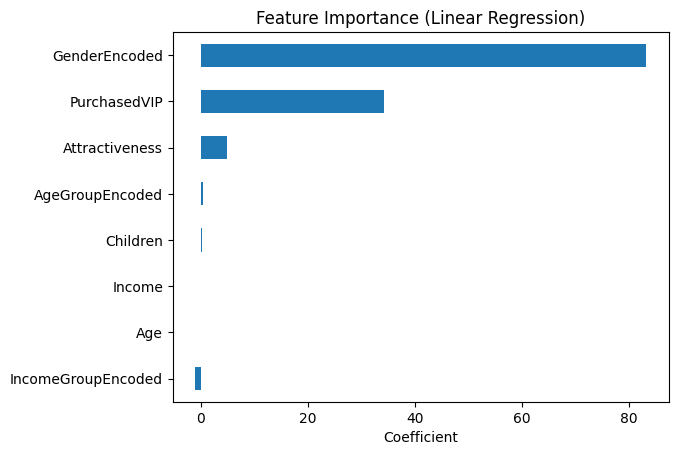

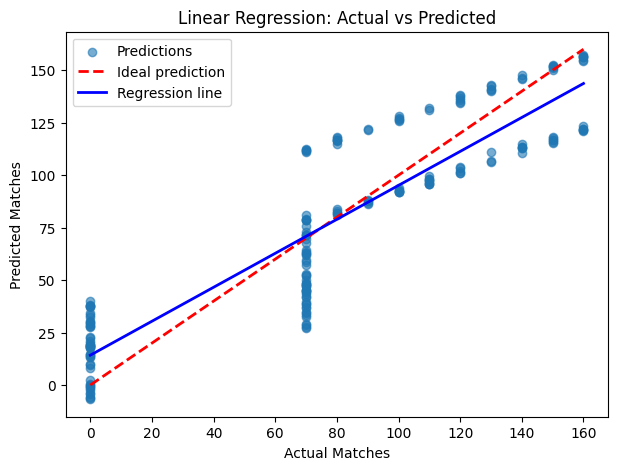

In [100]:
y_pred = linreg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

feature_importance = pd.Series(linreg.coef_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (Linear Regression)')
plt.xlabel('Coefficient')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal prediction')

reg_line = LinearRegression()
reg_line.fit(y_test.values.reshape(-1, 1), y_pred)
line_y = reg_line.predict(np.array([y_test.min(), y_test.max()]).reshape(-1, 1))
plt.plot([y_test.min(), y_test.max()], line_y, 'b-', lw=2, label='Regression line')

plt.xlabel('Actual Matches')
plt.ylabel('Predicted Matches')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()

The results are not great. MAE = 18 and we can see that predictions are rarely correct. Let's try another models.

# Decision Tree

## Function

In [101]:
def test_tree_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Model accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    importances = pd.Series(clf.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', figsize=(6,4))
    plt.title('Feature Importance')
    plt.xlabel('Importance')
    plt.show()

## Test

Model accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        64
         Low       1.00      1.00      1.00        52
      Medium       1.00      1.00      1.00        53
    VeryHigh       1.00      1.00      1.00        31

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



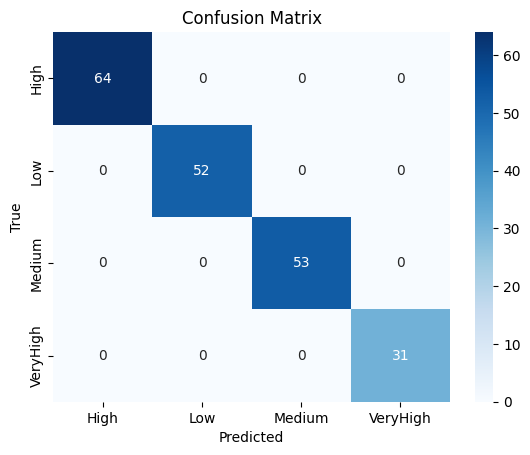

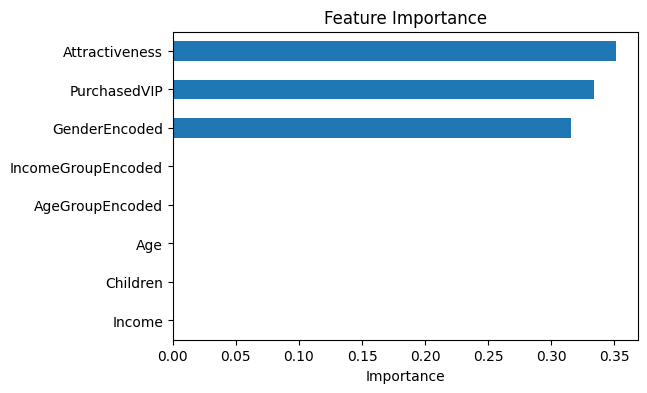

In [102]:
y = df.dropna(subset=['MatchesGroup'])['PopularityClass'].astype(str)
X = df[['PurchasedVIP', 'Income', 'Children', 'Age','AgeGroupEncoded' ,'IncomeGroupEncoded','Attractiveness','GenderEncoded']]
test_tree_model(X, y)

Model accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
         100       1.00      1.00      1.00        12
         110       1.00      1.00      1.00         8
         120       1.00      1.00      1.00        12
         130       1.00      1.00      1.00        13
         140       1.00      1.00      1.00         8
         150       1.00      1.00      1.00        12
         160       1.00      1.00      1.00        11
          70       1.00      1.00      1.00        53
          80       1.00      1.00      1.00        10
          90       1.00      1.00      1.00         9

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



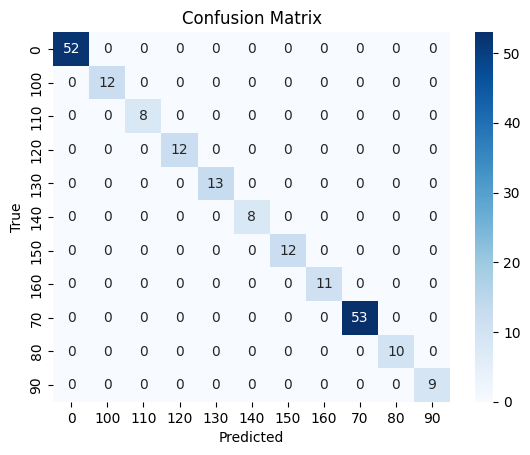

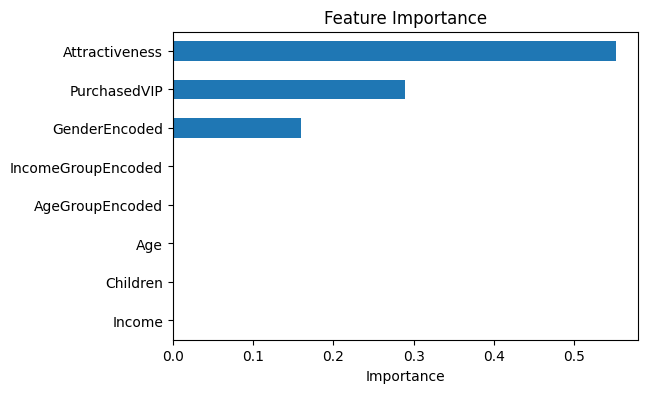

In [103]:
y = df.dropna(subset=['PopularityClass'])['MatchesGroup'].astype(str)
X = df[['PurchasedVIP', 'Income', 'Children', 'Age','AgeGroupEncoded' ,'IncomeGroupEncoded','Attractiveness','GenderEncoded']]
test_tree_model(X, y)

## Test conclusion

Looks like the dataset is perfectly balanced to work even on simple models, like DecisionTreeClassifier. Attractiveness, PurchasedVIp and Gender are only features that really matter. Let's see how other models work

# RandomForest

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

scores = cross_val_score(rf_model, X, y, cv=5)  # 5 katlı çapraz doğrulama

print("CV Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())

Confusion Matrix:
[[49  0  0  0  0  0  0  0  0  0  0]
 [ 0 11  0  0  0  0  0  0  0  0  1]
 [ 0  2  8  1  0  0  0  0  0  0  0]
 [ 0  0  0 11  0  0  0  0  0  0  0]
 [ 0  0  0  0  8  0  0  0  0  0  0]
 [ 0  0  0  0  1  8  0  0  0  0  0]
 [ 0  0  0  0  0  0 12  0  0  0  0]
 [ 0  0  0  0  0  0  0 13  0  0  0]
 [ 0  0  0  0  0  0  0  0 54  2  0]
 [ 0  2  0  0  0  0  0  0  1  7  2]
 [ 0  1  0  0  0  0  0  0  0  0  6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
         100       0.69      0.92      0.79        12
         110       1.00      0.73      0.84        11
         120       0.92      1.00      0.96        11
         130       0.89      1.00      0.94         8
         140       1.00      0.89      0.94         9
         150       1.00      1.00      1.00        12
         160       1.00      1.00      1.00        13
          70       0.98      0.96      0.97        56
          80       0

Mean Accuracy: 0.935 is a pretty good result.

# Neural Network

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 55732.8594 - mae: 201.1644 - val_loss: 3972.9487 - val_mae: 55.9078
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7479.4458 - mae: 68.9844 - val_loss: 5089.1914 - val_mae: 56.0472
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3875.2512 - mae: 50.4974 - val_loss: 3119.3203 - val_mae: 46.6552
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3135.3660 - mae: 45.9837 - val_loss: 3188.8550 - val_mae: 45.5154
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3007.4626 - mae: 45.8992 - val_loss: 3176.5603 - val_mae: 47.8538
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3037.2834 - mae: 45.6896 - val_loss: 3137.0933 - val_mae: 45.4907
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3305.3613 - mae: 46.8401 - val_loss: 3162.8979 - val_mae: 47.6701
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2980.6948 - mae: 44.6268 - val_loss: 3319.8171 - val_mae: 46.0085
Epoch 9/1

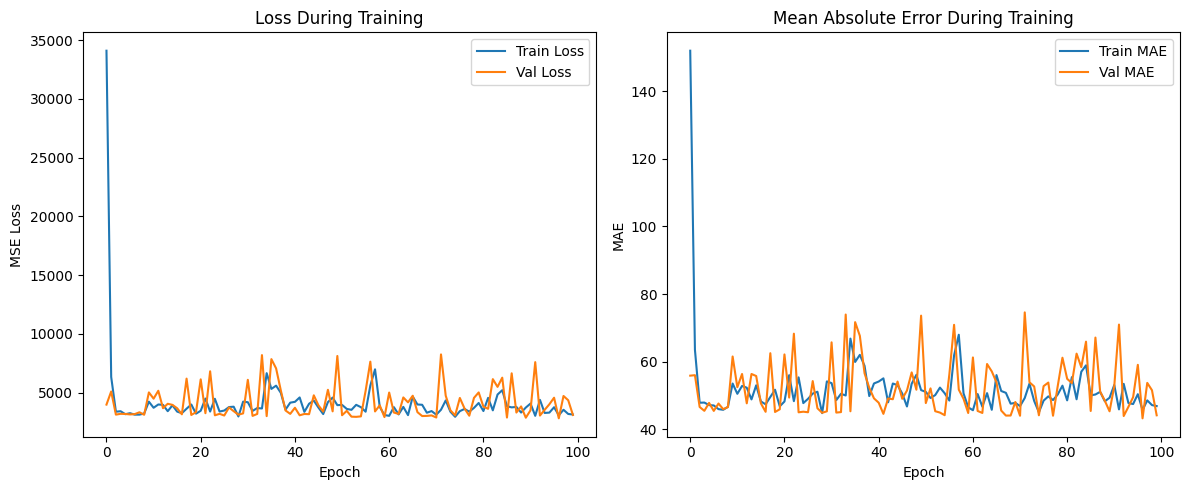

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2952.4314 - mae: 43.4554  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test MAE: 42.42632293701172
Test MSE: 2862.276560856715


In [105]:
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# Define the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Single output for regression
])
 
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
 
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)
 
# Plot training history
plt.figure(figsize=(12, 5))
 
# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
 
# MAE plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error During Training')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
 
plt.tight_layout()
plt.show()
 
# Evaluate on test set
loss, mae = model.evaluate(X_test, y_test, verbose=1)
y_pred = model.predict(X_test)
 
print("Test MAE:", mae)
print("Test MSE:", mean_squared_error(y_test, y_pred))

The NN contains three simple layers, the last one with only one output (standard for regression).

The neural network is redundant, since the dataset is quite simple and the decision tree copes much better.